In [43]:
import pandas as pd
import os
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!ls

 c5-c7	'Training with all genes expression.ipynb'   Untitled.ipynb


In [3]:
!pwd
i


/home/ouahbi/environment/dina datasets/Chemoterapy_cohorts/commun_data


In [7]:
os.chdir('c5-c7')

In [8]:
os.getcwd()

'/home/ouahbi/environment/dina datasets/Chemoterapy_cohorts/commun_data/c5-c7'

In [10]:
!ls

 05_hatzis_2011_merge_communc07_resp_gene.csv
'07_Magbanua MJ_2015_merge_resp_gene.csv'


In [12]:
c5 = pd.read_csv('05_hatzis_2011_merge_communc07_resp_gene.csv', sep='\t')
c5.head()

,Patient,response,RFC2,PAX8,GUCA1A,THRA,PTPN21,CCL5,CYP2E1,EPHB3,...,TRDN,OR7E47P,SCAF4,ALS2CL,LAMA1,FBXO31,SLC44A1,NUS1P3,RBM12B,NPEPL1
0,GSM615096,NonResponder,8.021741,10.840949,7.874062,8.256335,6.485966,6.495728,7.063123,8.539362,...,5.258077,6.224040,7.278666,9.404019,6.740287,7.902125,6.605087,5.002569,9.464399,8.356148
1,GSM615097,NonResponder,7.842947,11.715159,7.347955,7.983681,7.330512,7.332244,7.033859,9.188714,...,2.585735,5.834062,6.669256,8.772012,6.340898,6.887984,4.869042,5.677678,7.712806,7.388928
2,GSM615098,NonResponder,8.776267,10.715077,6.523880,7.820261,6.423794,10.066291,6.661108,10.387343,...,6.183848,7.720553,6.950571,9.162479,5.306158,6.602849,7.247321,6.552559,8.449233,8.299626
3,GSM615099,Responder,9.523877,10.750475,6.478643,7.526617,7.276040,10.399704,6.642930,9.836355,...,3.395661,5.730234,7.118569,9.303078,7.683123,7.862459,7.433980,6.894852,8.628715,7.364660
4,GSM615100,NonResponder,6.836237,10.827725,7.336754,8.312127,6.832232,7.090151,7.081613,8.918156,...,2.324113,5.336347,7.290629,8.260585,7.878409,8.275384,7.049621,6.145962,8.100091,7.269608


In [19]:
print(c5.shape)
print(c5.dtypes.unique().tolist())
c5.dtypes.value_counts(normalize=True)

(306, 8995)
[dtype('O'), dtype('float64')]


float64    0.999778
object     0.000222
dtype: float64

In [21]:
c5.set_index('Patient', inplace=True)

In [24]:
c5['response']=c5['response'].map({'NonResponder':0, 'Responder':1})

In [29]:
c5.isna().sum(axis=0).sort_values(ascending=False).head(5)

NPEPL1     0
ITGBL1     0
BMP5       0
MPP6       0
ZNF354A    0
dtype: int64

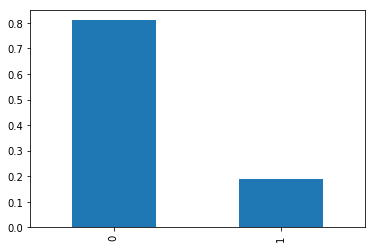

In [38]:
c5.iloc[:,0].value_counts(normalize=True).round(2).plot.bar()

In [39]:
#split
X = c5.drop('response', axis=1)
y = c5['response']

print(X.shape, y.shape)

(306, 8993) (306,)


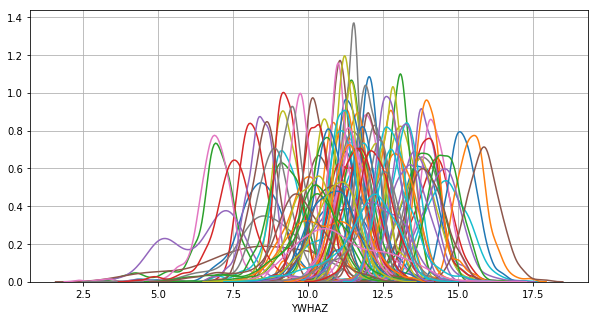

In [46]:
# dist of some genes expression 
plt.figure(figsize=(10,5))
for col in X.columns[:100]:
    sns.distplot(X[col], hist=False)
    plt.xlabe
    plt.grid(True)

In [51]:
#untill 100
c5.columns.get_loc('YWHAZ')

100

In [55]:
X.std(axis=0).sort_values(ascending=False).head()

AGR2       3.761116
SCGB2A2    3.600154
S100A7     3.403502
LTF        3.334582
GABRP      3.217137
dtype: float64

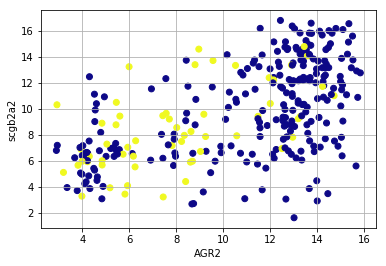

In [59]:
#let's see if best two features can separate our patient
plt.scatter(x = 'AGR2', y = 'SCGB2A2', data=X, c=y, cmap='plasma')
plt.xlabel('AGR2')
plt.ylabel('scgb2a2')
plt.grid(True)

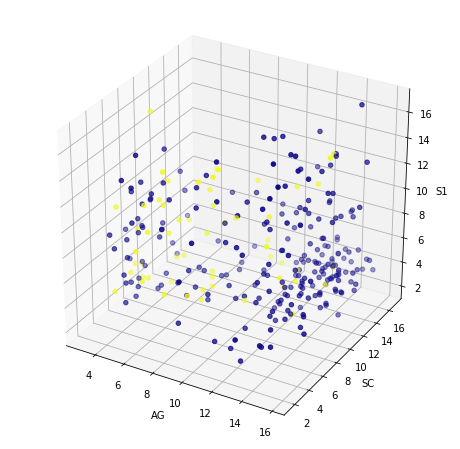

In [72]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X['AGR2'], X['SCGB2A2'],X['S100A7'], c=y, cmap='plasma')
ax.set_xlabel('AG')
ax.set_ylabel('SC')
ax.set_zlabel('S1')
plt.show()

===> small ccl : 
- shape of data : (306, 8995)
- types of data : one object and 8993 floats
- unbalance data 
    - mcc / score f1
- no scall data 
    - robustscaller / minmax

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

print('train shape ===> ',X_train.shape)
print('test shape ===> ',X_test.shape)

train shape ===>  (229, 8993)
test shape ===>  (77, 8993)


In [74]:
#pca-dt / dt/ stack / knn

# tts-all feature

In [132]:
# IMPORT CLF

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, matthews_corrcoef
from sklearn.ensemble import BaggingClassifier

In [106]:
#models initialisation 
knn = KNeighborsClassifier(n_neighbors=5, p=2)
lr = LogisticRegression(penalty='l2',
                        random_state=0)
rf =RandomForestClassifier(n_estimators = 20, 
                                criterion = 'entropy', 
                                random_state = 51)
svc_lm = SVC(random_state=0, kernel='linear')
svc_rbf = SVC(random_state=0, kernel='rbf')
dt =  DecisionTreeClassifier(criterion = 'entropy',random_state = 0, max_depth=None)

# make dictionnary
pred_list = {}
mcc_score = {}
score_f1 = {}

#put models inside list 6
models = [knn,lr,rf,svc_lm,svc_rbf,dt]

#fit, predict and evaluate inside for loop
for clf in models:
    clf.fit(X_train, y_train)
    pred_list[clf] = clf.predict(X_test)
    mcc_score[clf] = matthews_corrcoef(y_test, pred_list[clf])
    score_f1[clf] = f1_score(y_test, pred_list[clf])
    

/home/ouahbi/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
/home/ouahbi/anaconda3/lib/python3.7/site-packages/sklearn/svm/base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
/home/ouahbi/anaconda3/lib/python3.7/site-packages/sklearn/metrics/classification.py:543: RuntimeWarning: invalid value encountered in double_scalars
/home/ouahbi/anaconda3/lib/python3.7/site-packages/sklearn/metrics/classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.


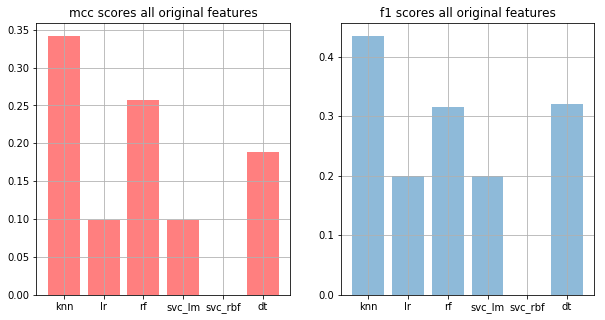

In [128]:
list_models = ['knn','lr','rf','svc_lm','svc_rbf','dt']
plt.figure(figsize=(10,5))
plt.subplot(121)
plt.bar(list_models, mcc_score.values(), alpha=0.5, color='red')
plt.grid(True)
plt.title('mcc scores all original features')
plt.subplot(122)
plt.bar(list_models, score_f1.values(), alpha=0.5)
plt.grid(True)
plt.title('f1 scores all original features')
plt.savefig("05_hatzis_2011_mccf1 scores all original features.png")

In [137]:
# chaque model est faible ===> maybe together is more better 
from sklearn.ensemble import AdaBoostClassifier

ab = AdaBoostClassifier(n_estimators=100, random_state=0)
ab.fit(X_train, y_train)
print(matthews_corrcoef(y_test, ab.predict(X_test)))
print(f1_score(y_test, ab.predict(X_test)))

0.11322770341445958
0.24999999999999994


# cv-all feature

In [143]:
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(10, random_state=0)

# make dictionnary
pred_cv = {}
mcc_cv = {}
f1_cv = {}

#model in for loop 
for clf in models:
    np.average(cross_val_score(clf, X, y, cv=cv))
    pred_cv[clf] = cross_val_predict(clf, X, y, cv=cv)
    mcc_cv[clf] = matthews_corrcoef(y, pred_cv[clf])
    f1_cv[clf] = f1_score(y, pred_cv[clf])
    

/home/ouahbi/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
/home/ouahbi/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
/home/ouahbi/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
/home/ouahbi/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
/home/ouahbi/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
/home/ouahbi/an

/home/ouahbi/anaconda3/lib/python3.7/site-packages/sklearn/svm/base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
/home/ouahbi/anaconda3/lib/python3.7/site-packages/sklearn/svm/base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
/home/ouahbi/anaconda3/lib/python3.7/site-packages/sklearn/svm/base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
/home/ouahbi/anaconda3/lib/python3.7/site-packages/sklearn/svm/base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to acc

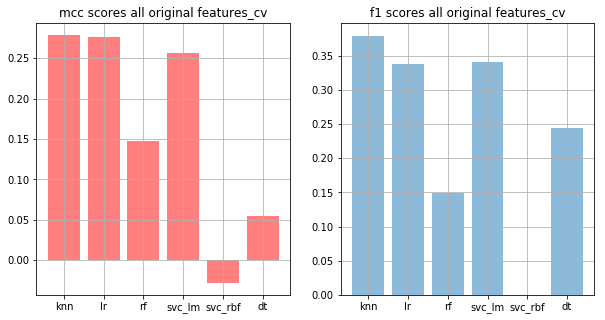

In [147]:
list_models = ['knn','lr','rf','svc_lm','svc_rbf','dt']
plt.figure(figsize=(10,5))
plt.subplot(121)
plt.bar(list_models, mcc_cv.values(), alpha=0.5, color='red')
plt.grid(True)
plt.title('mcc scores all original features_cv')
plt.subplot(122)
plt.bar(list_models, f1_cv.values(), alpha=0.5)
plt.grid(True)
plt.title('f1 scores all original features_cv')
plt.savefig("05_hatzis_2011_mccf1 scores all original features_cv.png")

# all-feature_sc_tss

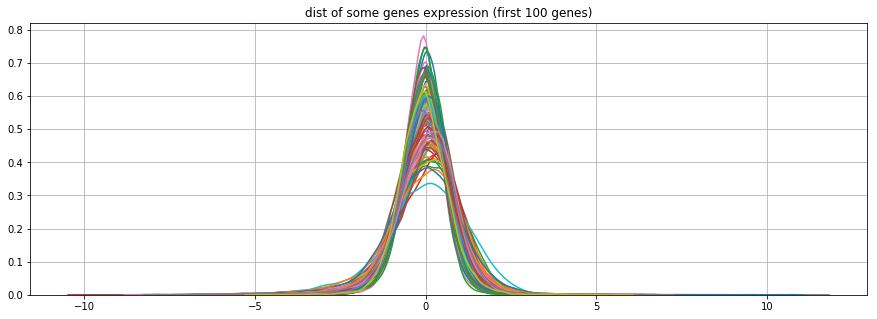

In [160]:
#transform data into normal distribution
from sklearn.preprocessing import RobustScaler

X_train_rb = RobustScaler().fit_transform(X_train)
X_test_rb = RobustScaler().fit_transform(X_test)

#check if it's normal
plt.figure(figsize=(15,5))
for row in X_train_rb[1:100]:
    sns.distplot(row, hist=False)
    plt.grid(True)
    plt.title('dist of some genes expression (first 100 genes)')


In [161]:
# make dictionnary
pred_rb = {}
mcc_rb = {}
f1_rb = {}

#fit, predict and evaluate inside for loop
for clf in models:
    clf.fit(X_train_rb, y_train)
    pred_rb[clf] = clf.predict(X_test_rb)
    mcc_rb[clf] = matthews_corrcoef(y_test, pred_rb[clf])
    f1_rb[clf] = f1_score(y_test, pred_rb[clf])

/home/ouahbi/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
/home/ouahbi/anaconda3/lib/python3.7/site-packages/sklearn/svm/base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
/home/ouahbi/anaconda3/lib/python3.7/site-packages/sklearn/metrics/classification.py:543: RuntimeWarning: invalid value encountered in double_scalars
/home/ouahbi/anaconda3/lib/python3.7/site-packages/sklearn/metrics/classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.


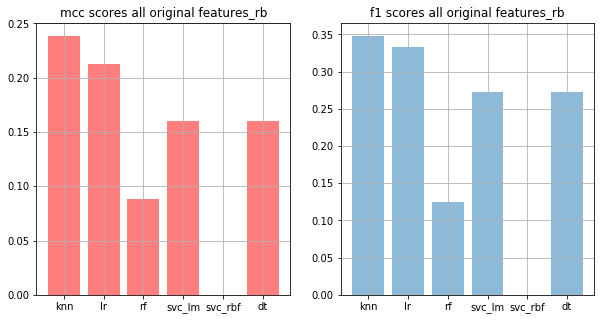

In [166]:
plt.figure(figsize=(10,5))
plt.subplot(121)
plt.bar(list_models, mcc_rb.values(), alpha=0.5, color='red')
plt.grid(True)
plt.title('mcc scores all original features_rb')
plt.subplot(122)
plt.bar(list_models, f1_rb.values(), alpha=0.5)
plt.grid(True)
plt.title('f1 scores all original features_rb')
plt.savefig("05_hatzis_2011_mccf1 scores all original features_rb.png")

In [170]:
#cv
# make dictionnary
pred_rb_cv = {}
mcc_rb_cv = {}
f1_rb_cv = {}

#model in for loop 
for clf in models:
    np.average(cross_val_score(clf, X_train_rb, y_train, cv=cv))
    pred_rb_cv[clf] = cross_val_predict(clf, X_test_rb, y_test, cv=cv)
    mcc_rb_cv[clf] = matthews_corrcoef(y_test, pred_rb_cv[clf])
    f1_rb_cv[clf] = f1_score(y_test, pred_rb_cv[clf])
    

/home/ouahbi/anaconda3/lib/python3.7/site-packages/sklearn/metrics/classification.py:543: RuntimeWarning: invalid value encountered in double_scalars
/home/ouahbi/anaconda3/lib/python3.7/site-packages/sklearn/metrics/classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
/home/ouahbi/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
/home/ouahbi/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
/home/ouahbi/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
/home/ouahbi/anaconda3/lib/python3.7/site-packages/sklearn/linear_model

/home/ouahbi/anaconda3/lib/python3.7/site-packages/sklearn/svm/base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
/home/ouahbi/anaconda3/lib/python3.7/site-packages/sklearn/svm/base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
/home/ouahbi/anaconda3/lib/python3.7/site-packages/sklearn/metrics/classification.py:543: RuntimeWarning: invalid value encountered in double_scalars
/home/ouahbi/anaconda3/lib/python3.7/site-packages/sklearn/metrics/classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.


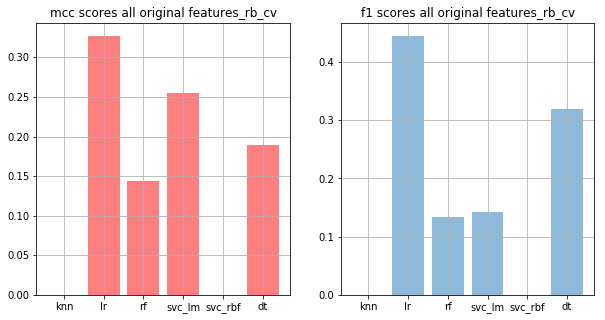

In [172]:
plt.figure(figsize=(10,5))
plt.subplot(121)
plt.bar(list_models, mcc_rb_cv.values(), alpha=0.5, color='red')
plt.grid(True)
plt.title('mcc scores all original features_rb_cv')
plt.subplot(122)
plt.bar(list_models, f1_rb_cv.values(), alpha=0.5)
plt.grid(True)
plt.title('f1 scores all original features_rb_cv')
plt.savefig("05_hatzis_2011_mccf1 scores all original features_rb_cv.png")

# features selection_tss

In [197]:
#minmax
#no outlier (see distribution)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_sc = scaler.fit_transform(X)

In [198]:
X_sc.min()

0.0

In [201]:
#freature selection ANOVA
# Feature Selection with Univariate Statistical Tests
from numpy import set_printoptions
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif, chi2

kb = SelectKBest(chi2, k=4000)
best_f = kb.fit_transform(X_sc,y)

In [206]:
#get the index of best features with get_support function ==> boolean mask
best_f_name = np.array(pd.DataFrame(X).columns)[kb.get_support()]
best_f_name

array(['RFC2', 'PAX8', 'GUCA1A', ..., 'SMEK2', 'OR7E47P', 'NUS1P3'],
      dtype=object)

In [208]:
X_train_bf, X_test_bf, y_train_bf, y_test_bf = train_test_split(best_f, y, random_state=0)

print(X_train_bf.shape, X_test_bf.shape)

(229, 4000) (77, 4000)


In [209]:
# make dictionnary
pred_bf = {}
mcc_bf = {}
f1_bf = {}

#fit, predict and evaluate inside for loop
for clf in models:
    clf.fit(X_train_bf, y_train_bf)
    pred_bf[clf] = clf.predict(X_test_bf)
    mcc_bf[clf] = matthews_corrcoef(y_test_bf, pred_bf[clf])
    f1_bf[clf] = f1_score(y_test_bf, pred_bf[clf])
    

/home/ouahbi/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
/home/ouahbi/anaconda3/lib/python3.7/site-packages/sklearn/svm/base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
/home/ouahbi/anaconda3/lib/python3.7/site-packages/sklearn/metrics/classification.py:543: RuntimeWarning: invalid value encountered in double_scalars
/home/ouahbi/anaconda3/lib/python3.7/site-packages/sklearn/metrics/classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.


In [210]:
mcc_bf.values()

dict_values([0.44467121718097274, 0.5478027946596923, 0.2675837217835722, 0.5965199110453098, 0.0, 0.16706730769230768])

In [211]:
f1_bf.values()

dict_values([0.5217391304347826, 0.608695652173913, 0.25, 0.6666666666666666, 0.0, 0.3076923076923077])

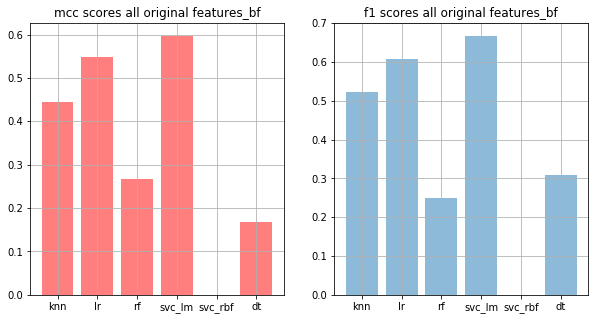

In [213]:
plt.figure(figsize=(10,5))
plt.subplot(121)
plt.bar(list_models, mcc_bf.values(), alpha=0.5, color='red')
plt.grid(True)
plt.title('mcc scores all original features_bf')
plt.subplot(122)
plt.bar(list_models, f1_bf.values(), alpha=0.5)
plt.grid(True)
plt.title('f1 scores all original features_bf')
plt.savefig("05_hatzis_2011_mccf1 scores all original features_bf.png")